In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
folder="/content/drive/MyDrive/python與生成式AI/長榮海運-決策樹程式/Evergreen Marine/stocks_202101_202607.xlsx"

#環境準備與資料載入

##載入長榮海運歷史交易資料

In [12]:
import pandas as pd
import os

file_name = 'stocks_202101_202607.xlsx'
df = pd.read_excel(folder) # 直接使用 folder 變數，它已經是完整的檔案路徑
df

,date,week,stock_id,Trading_Volume,Trading_money,open,max,min,close,spread,...,MA11,MA12,MA13,MA14,MA15,MA16,MA17,MA18,MA19,MA20
0,2021-01-04,1,2603,513948027,22520200069,42.35,44.75,42.15,44.75,4.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-05,2,2603,534170709,23771908658,45.00,45.50,43.15,45.50,0.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-06,3,2603,564485036,24995780260,44.75,46.20,42.25,42.55,-2.95,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-07,4,2603,776225788,30670337681,43.30,43.80,38.30,38.45,-4.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-08,5,2603,548832487,21628019137,38.50,40.75,37.20,40.30,1.85,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1340,2026-07-27,1,2603,6810641,1388066244,203.50,206.00,202.50,203.50,-2.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1341,2026-07-28,2,2603,7097030,1420735979,203.00,203.00,199.00,200.00,-3.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1342,2026-07-29,3,2603,13258719,2681322989,205.00,205.50,198.00,201.50,1.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1343,2026-07-30,4,2603,6941425,1395015033,202.50,202.50,199.50,201.00,-0.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#資料前處理與特徵工程

##缺失值處理

In [14]:
import os
import pandas as pd

# 1. 載入資料
file_name = 'stocks_202101_202607.xlsx'
df = pd.read_excel(folder) # 直接使用 folder 變數，它已經是完整的檔案路徑

# 2. 定義欲刪除的欄位清單 (包含 MA5~MA20 以及 Unnamed: 12)
drop_cols = [f'MA{i}' for i in range(5, 21)] + ['Unnamed: 12']

# 3. 執行刪除 (errors='ignore' 確保即便某些欄位名稱微幅不同也不會報錯)
df = df.drop(columns=drop_cols, errors='ignore')

# 4. 檢查刪除後的欄位清單與資料筆數
print("刪除後的欄位清單：")
print(df.columns.tolist())

print(f"\n清理完成後的總資料筆數：{df.shape[0]} 筆")
df.head()

刪除後的欄位清單：
['date', 'week', 'stock_id', 'Trading_Volume', 'Trading_money', 'open', 'max', 'min', 'close', 'spread', 'Trading_turnover', '20MA']

清理完成後的總資料筆數：1345 筆


,date,week,stock_id,Trading_Volume,Trading_money,open,max,min,close,spread,Trading_turnover,20MA
0,2021-01-04,1,2603,513948027,22520200069,42.35,44.75,42.15,44.75,4.05,128029,NaN
1,2021-01-05,2,2603,534170709,23771908658,45.00,45.50,43.15,45.50,0.75,151367,NaN
2,2021-01-06,3,2603,564485036,24995780260,44.75,46.20,42.25,42.55,-2.95,167792,NaN
3,2021-01-07,4,2603,776225788,30670337681,43.30,43.80,38.30,38.45,-4.10,219953,NaN
4,2021-01-08,5,2603,548832487,21628019137,38.50,40.75,37.20,40.30,1.85,156175,NaN


In [ ]:
df

##重複資料處理

In [15]:
# ==========================================
#  重複資料處理 (接續使用清理好的 df_clean)
# ==========================================
# 檢查是否有重複列 (不需要重新 pd.read_excel)
duplicates = df[df.duplicated()]
print(f"重複資料筆數：{duplicates.shape[0]} 筆")

# 執行刪除重複列，並更新 df_clean
df_clean = df.copy() # Initialize df_clean with a copy of df
df_clean = df_clean.drop_duplicates()

print(f"最終處理完成的資料筆數：{df_clean.shape[0]} 筆，欄位數量：{df_clean.shape[1]} 個")

# 預覽乾淨的資料結果
df_clean.head()

重複資料筆數：0 筆
最終處理完成的資料筆數：1345 筆，欄位數量：12 個


,date,week,stock_id,Trading_Volume,Trading_money,open,max,min,close,spread,Trading_turnover,20MA
0,2021-01-04,1,2603,513948027,22520200069,42.35,44.75,42.15,44.75,4.05,128029,NaN
1,2021-01-05,2,2603,534170709,23771908658,45.00,45.50,43.15,45.50,0.75,151367,NaN
2,2021-01-06,3,2603,564485036,24995780260,44.75,46.20,42.25,42.55,-2.95,167792,NaN
3,2021-01-07,4,2603,776225788,30670337681,43.30,43.80,38.30,38.45,-4.10,219953,NaN
4,2021-01-08,5,2603,548832487,21628019137,38.50,40.75,37.20,40.30,1.85,156175,NaN


##異常值處理

In [18]:
# 1. 替換為實際欲分析的數值欄位名稱
colname = 'close'

# 2. 計算 IQR 與邊界
Q1 = df[colname].quantile(0.25)
Q3 = df[colname].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

# 3. 篩選離群值資料
df1 = df[(df[colname] < lower) | (df[colname] > upper)]

print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR, "upper:", upper, "lower:", lower)
print("離群值總筆數:", df1.shape[0])
df1


Q1: 126.0 Q3: 195.0 IQR: 69.0 upper: 298.5 lower: 22.5
離群值總筆數: 0


,date,week,stock_id,Trading_Volume,Trading_money,open,max,min,close,spread,Trading_turnover,20MA,z_score


In [19]:
import numpy as np

# 1. 指定欲分析的數值欄位
colname = 'close'

# 2. 計算平均值、標準差與 Z-score
mean = df[colname].mean()
std = df[colname].std()

# 計算每個數值的 Z-score
df['z_score'] = (df[colname] - mean) / std

# 3. 設定閥值（通常取 3，若資料量較小可調整為 2.5 或 2）
threshold = 3

# 4. 篩選離群值資料 (|Z| > threshold)
df_z_outliers = df[df['z_score'].abs() > threshold]

print("Mean:", round(mean, 2), "Std:", round(std, 2))
print("離群值總筆數 (Z-score):", df_z_outliers.shape[0])

# 顯示離群值結果（可將輔助用的 z_score 欄位移除或留著檢視）
df_z_outliers

Mean: 157.2 Std: 48.42
離群值總筆數 (Z-score): 0


,date,week,stock_id,Trading_Volume,Trading_money,open,max,min,close,spread,Trading_turnover,20MA,z_score


In [20]:
df = df.drop(columns=['z_score'], errors='ignore')

In [21]:
df

,date,week,stock_id,Trading_Volume,Trading_money,open,max,min,close,spread,Trading_turnover,20MA
0,2021-01-04,1,2603,513948027,22520200069,42.35,44.75,42.15,44.75,4.05,128029,NaN
1,2021-01-05,2,2603,534170709,23771908658,45.00,45.50,43.15,45.50,0.75,151367,NaN
2,2021-01-06,3,2603,564485036,24995780260,44.75,46.20,42.25,42.55,-2.95,167792,NaN
3,2021-01-07,4,2603,776225788,30670337681,43.30,43.80,38.30,38.45,-4.10,219953,NaN
4,2021-01-08,5,2603,548832487,21628019137,38.50,40.75,37.20,40.30,1.85,156175,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1340,2026-07-27,1,2603,6810641,1388066244,203.50,206.00,202.50,203.50,-2.50,5256,195.68
1341,2026-07-28,2,2603,7097030,1420735979,203.00,203.00,199.00,200.00,-3.50,7590,196.48
1342,2026-07-29,3,2603,13258719,2681322989,205.00,205.50,198.00,201.50,1.50,19819,197.33
1343,2026-07-30,4,2603,6941425,1395015033,202.50,202.50,199.50,201.00,-0.50,5228,198.10


##特徵衍生

In [22]:
import pandas as pd
import numpy as np

# (1) 計算 5 日均線
df['MA_5'] = df['close'].rolling(window=5).mean()

# (2) 計算收盤價相對於 20 日均線的乖離率
df['BIAS_20'] = (df['close'] - df['20MA']) / df['20MA']

# (3) 計算 MA_5 與 20日均線的差值 (判斷均線糾結或黃金/死亡交叉)
df['MA_diff'] = df['MA_5'] - df['20MA']

# (4) 當日漲跌幅與振幅
df['daily_return'] = df['close'].pct_change()
df['amplitude'] = (df['max'] - df['min']) / df['open']

# 3. 建立目標變數 Target (預測明日收盤價是否高於今日收盤價)
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

# 4. 清理因計算均線與 shift 產生的空值
df_clean = df.dropna().copy()
df

#技術分析衍生特徵
#MA_5：近 5 個交易日的收盤平均價，反映短期價格趨勢
#BIAS_20：20 日乖離率，衡量收盤價偏離 20 日均線的程度，可用於觀察價格是否過度偏離均值。
#MA_diff：短均線與中均線之差值（MA\_5-MA\_20），可用於判斷短線與中線之多空交叉狀態。

#波動度與報酬率指標
#daily_return：當日漲跌幅比例（(close_t-close_t-1)/close_t-1）
#amplitude：當日振幅比例（max-min)/open），反映當日盤中價格劇烈程度。

#機器學習目標變數
#target：預測目標（標籤y）。若下一交易日收盤價高於當日收盤價則標記為1（預期上漲/買進訊號），反之則標記為0。

,date,week,stock_id,Trading_Volume,Trading_money,open,max,min,close,spread,Trading_turnover,20MA,MA_5,BIAS_20,MA_diff,daily_return,amplitude,target
0,2021-01-04,1,2603,513948027,22520200069,42.35,44.75,42.15,44.75,4.05,128029,NaN,NaN,NaN,NaN,NaN,0.061393,1
1,2021-01-05,2,2603,534170709,23771908658,45.00,45.50,43.15,45.50,0.75,151367,NaN,NaN,NaN,NaN,0.016760,0.052222,0
2,2021-01-06,3,2603,564485036,24995780260,44.75,46.20,42.25,42.55,-2.95,167792,NaN,NaN,NaN,NaN,-0.064835,0.088268,0
3,2021-01-07,4,2603,776225788,30670337681,43.30,43.80,38.30,38.45,-4.10,219953,NaN,NaN,NaN,NaN,-0.096357,0.127021,1
4,2021-01-08,5,2603,548832487,21628019137,38.50,40.75,37.20,40.30,1.85,156175,NaN,42.31,NaN,NaN,0.048114,0.092208,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1340,2026-07-27,1,2603,6810641,1388066244,203.50,206.00,202.50,203.50,-2.50,5256,195.68,204.40,0.039963,8.72,-0.012136,0.017199,0
1341,2026-07-28,2,2603,7097030,1420735979,203.00,203.00,199.00,200.00,-3.50,7590,196.48,203.80,0.017915,7.32,-0.017199,0.019704,1
1342,2026-07-29,3,2603,13258719,2681322989,205.00,205.50,198.00,201.50,1.50,19819,197.33,202.90,0.021132,5.57,0.007500,0.036585,0
1343,2026-07-30,4,2603,6941425,1395015033,202.50,202.50,199.50,201.00,-0.50,5228,198.10,202.40,0.014639,4.30,-0.002481,0.014815,1


In [23]:
# ==========================================
#  建立目標變數 (Target Variable)
# ==========================================

# 1. 計算下一個交易日的收盤價 (將 close_收盤價 向上移動一格)
df['next_close'] = df['close'].shift(-1)

# 2. 定義目標變數 target：
# 若明日收盤價 > 今日收盤價，標記為 1 (預期上漲/買進)；否則標記為 0 (預期持平或下跌/不買進)
df['target'] = (df['next_close'] > df['close']).astype(int)

# 3. 檢視目標變數的分佈比例 (檢查是否有類別不平衡問題)
print("--- 目標變數分佈統計 ---")
print(df['target'].value_counts())
print("\n比例分佈：")
print(df['target'].value_counts(normalize=True).map(lambda n: f"{n:.2%}"))

# 4. 預覽資料（顯示日期、今日收盤價、明日收盤價與 target）
print("\n--- 資料前 5 筆檢視 ---")
display(df[['date', 'close', 'next_close', 'target']].head())

# 5. 處理最後一筆無明日價格的資料列
# 因 shift(-1) 會導致最後一筆資料沒有「明日收盤價」(NaN)，需予以剔除
df_model = df.dropna(subset=['next_close']).copy()

# 移除輔助用的 next_close 欄位，保留乾淨的特徵與 target
df_model = df_model.drop(columns=['next_close'])

print(f"\n清理完畢，可用於訓練的資料總筆數為：{df_model.shape[0]} 筆")

--- 目標變數分佈統計 ---
target
0    680
1    665
Name: count, dtype: int64

比例分佈：
target
0    50.56%
1    49.44%
Name: proportion, dtype: object

--- 資料前 5 筆檢視 ---


,date,close,next_close,target
0,2021-01-04,44.75,45.50,1
1,2021-01-05,45.50,42.55,0
2,2021-01-06,42.55,38.45,0
3,2021-01-07,38.45,40.30,1
4,2021-01-08,40.30,42.65,1



清理完畢，可用於訓練的資料總筆數為：1344 筆


In [24]:
df

,date,week,stock_id,Trading_Volume,Trading_money,open,max,min,close,spread,Trading_turnover,20MA,MA_5,BIAS_20,MA_diff,daily_return,amplitude,target,next_close
0,2021-01-04,1,2603,513948027,22520200069,42.35,44.75,42.15,44.75,4.05,128029,NaN,NaN,NaN,NaN,NaN,0.061393,1,45.50
1,2021-01-05,2,2603,534170709,23771908658,45.00,45.50,43.15,45.50,0.75,151367,NaN,NaN,NaN,NaN,0.016760,0.052222,0,42.55
2,2021-01-06,3,2603,564485036,24995780260,44.75,46.20,42.25,42.55,-2.95,167792,NaN,NaN,NaN,NaN,-0.064835,0.088268,0,38.45
3,2021-01-07,4,2603,776225788,30670337681,43.30,43.80,38.30,38.45,-4.10,219953,NaN,NaN,NaN,NaN,-0.096357,0.127021,1,40.30
4,2021-01-08,5,2603,548832487,21628019137,38.50,40.75,37.20,40.30,1.85,156175,NaN,42.31,NaN,NaN,0.048114,0.092208,1,42.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1340,2026-07-27,1,2603,6810641,1388066244,203.50,206.00,202.50,203.50,-2.50,5256,195.68,204.40,0.039963,8.72,-0.012136,0.017199,0,200.00
1341,2026-07-28,2,2603,7097030,1420735979,203.00,203.00,199.00,200.00,-3.50,7590,196.48,203.80,0.017915,7.32,-0.017199,0.019704,1,201.50
1342,2026-07-29,3,2603,13258719,2681322989,205.00,205.50,198.00,201.50,1.50,19819,197.33,202.90,0.021132,5.57,0.007500,0.036585,0,201.00
1343,2026-07-30,4,2603,6941425,1395015033,202.50,202.50,199.50,201.00,-0.50,5228,198.10,202.40,0.014639,4.30,-0.002481,0.014815,1,204.00


###熱力圖

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24501 (\N{CJK UNIFIED IDEOGRAPH-5FB5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38364 (\N{CJK UNIFIED IDEOGRAPH-95DC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas

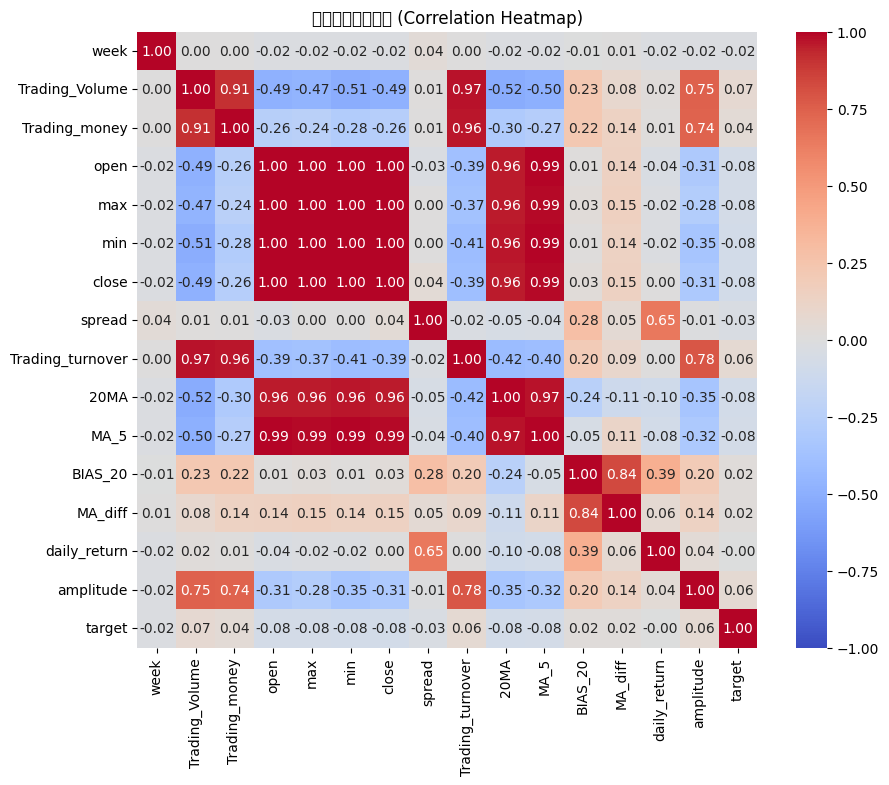

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 計算特徵矩陣與 target 的皮爾森相關係數
corr = df_clean.drop(columns=['date', 'stock_id'], errors='ignore').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('特徵相關性熱力圖 (Correlation Heatmap)')
plt.show()

###手動塞選特徵值

In [26]:
# 1. 建立目標變數 y
y = df_clean['target']

# 2. 手動指定明確需要的相對指標/特徵欄位
keep_features = [
    '20MA',
    'BIAS_20',       # 20日乖離率
    'MA_diff',       # 均線差
    'daily_return',  # 日報酬率
    'amplitude',     # 振幅
    'spread',        # 價差
    'week'           # 星期
]

# 3. 建立僅包含指定相對指標的特徵矩陣 X
X = df_clean[keep_features]

# 4. 檢查結果
print("--- 保留的相對指標特徵矩陣 ---")
print(X.head())

--- 保留的相對指標特徵矩陣 ---
     20MA   BIAS_20  MA_diff  daily_return  amplitude  spread  week
19  36.60 -0.147541    -3.43     -0.060241   0.080717   -2.00     5
20  35.92 -0.131403    -3.58      0.000000   0.058065    0.00     1
21  35.35 -0.035361    -2.92      0.092949   0.091772    2.90     2
22  34.90 -0.038682    -2.25     -0.016129   0.060029   -0.55     3
23  34.67 -0.020767    -1.87      0.011923   0.029806    0.40     4


#測試集、訓練集分割

##分離特徵

In [28]:
# 1. 建立目標變數 y (僅提取標籤欄位)
y = df_clean['target']

# 2. 定義明確要保留的「相對指標」與「衍生特徵」清單
#    (徹底排除 open, max, min, close, 20MA, MA_5 等絕對價格)
feature_list = [
    '20MA',
    'BIAS_20',       # 20日乖離率 (相對指標)
    'MA_diff',       # 均線差值 (衍生指標)
    'daily_return',  # 當日報酬率 (百分比)
    'amplitude',     # 振幅 (相對比例)
    'spread',        # 高低價差
    'week'           # 星期 (週期變數)
]

# 3. 建立特徵矩陣 X
X = df_clean[feature_list]

# 4. 檢查分離後的 X 與 y 狀態
print("=== 特徵與目標變數分離完成 ===")
print(f"特徵矩陣 X 的形狀 (筆數, 特徵數): {X.shape}")
print(f"目標變數 y 的形狀 (筆數,): {y.shape}")
print("\n--- 傳入模型的最終特徵欄位 ---")
print(X.columns.tolist())

# 5. 預覽前 5 筆特徵資料
print("\n--- 特徵矩陣 X 前 5 筆資料 ---")
print(X.head())

=== 特徵與目標變數分離完成 ===
特徵矩陣 X 的形狀 (筆數, 特徵數): (1326, 7)
目標變數 y 的形狀 (筆數,): (1326,)

--- 傳入模型的最終特徵欄位 ---
['20MA', 'BIAS_20', 'MA_diff', 'daily_return', 'amplitude', 'spread', 'week']

--- 特徵矩陣 X 前 5 筆資料 ---
     20MA   BIAS_20  MA_diff  daily_return  amplitude  spread  week
19  36.60 -0.147541    -3.43     -0.060241   0.080717   -2.00     5
20  35.92 -0.131403    -3.58      0.000000   0.058065    0.00     1
21  35.35 -0.035361    -2.92      0.092949   0.091772    2.90     2
22  34.90 -0.038682    -2.25     -0.016129   0.060029   -0.55     3
23  34.67 -0.020767    -1.87      0.011923   0.029806    0.40     4


In [29]:
X

,20MA,BIAS_20,MA_diff,daily_return,amplitude,spread,week
19,36.60,-0.147541,-3.43,-0.060241,0.080717,-2.00,5
20,35.92,-0.131403,-3.58,0.000000,0.058065,0.00,1
21,35.35,-0.035361,-2.92,0.092949,0.091772,2.90,2
22,34.90,-0.038682,-2.25,-0.016129,0.060029,-0.55,3
23,34.67,-0.020767,-1.87,0.011923,0.029806,0.40,4
...,...,...,...,...,...,...,...
1340,195.68,0.039963,8.72,-0.012136,0.017199,-2.50,1
1341,196.48,0.017915,7.32,-0.017199,0.019704,-3.50,2
1342,197.33,0.021132,5.57,0.007500,0.036585,1.50,3
1343,198.10,0.014639,4.30,-0.002481,0.014815,-0.50,4


##資料集分割

In [30]:
# ==========================================
#  資料集分割 (按時間順序切分 Train/Test)
# ==========================================

# 1. 設定切分比例 (80% 訓練集, 20% 測試集)
train_ratio = 0.8
train_size = int(len(X) * train_ratio)

# 2. 按時間順序切分特徵矩陣 X
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

# 3. 按時間順序切分目標變數 y
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

# 4. 驗證切分後的形狀與筆數
print("--- 時序資料集切分完成 ---")
print(f"原始資料總筆數：{len(X)} 筆")
print(f"訓練集 (Train Set) 筆數：{len(X_train)} 筆 ({len(X_train)/len(X):.1%})")
print(f"測試集 (Test Set)  筆數：{len(X_test)} 筆 ({len(X_test)/len(X):.1%})")

# 5. 驗證時間軸是否連續 (無重疊與洗牌)
if 'date' in df_clean.columns:
    train_dates = df_clean['date'].iloc[:train_size]
    test_dates = df_clean['date'].iloc[train_size:]
    print(f"\n訓練集時間區間：{train_dates.min()} 至 {train_dates.max()}")
    print(f"測試集時間區間：{test_dates.min()} 至 {test_dates.max()}")

--- 時序資料集切分完成 ---
原始資料總筆數：1326 筆
訓練集 (Train Set) 筆數：1060 筆 (79.9%)
測試集 (Test Set)  筆數：266 筆 (20.1%)

訓練集時間區間：2021-01-29 00:00:00 至 2025-06-27 00:00:00
測試集時間區間：2025-06-30 00:00:00 至 2026-07-31 00:00:00


#決策樹模型建構與訓練

##建立 DecisionTreeClassifier 模型

In [31]:
from sklearn.tree import DecisionTreeClassifier
model_bias = DecisionTreeClassifier(
    criterion='gini',         # 使用 Gini 不純度評估分割
    max_depth=3,              # 限制最大深度為 3，預防過擬合
    min_samples_split=10,     # 節點分割所需的最小樣本數
    min_samples_leaf=5,       # 葉子節點所需的最小樣本數
    random_state=42           # 固定隨機種子以重現結果
)

# ==========================================
# 步驟 3：進行模型訓練 (Fit)
# ==========================================
model_bias.fit(X_train, y_train)
print("--- 模型訓練完成 ---")

# ==========================================
# 步驟 4：進行預測與績效評估
# ==========================================
train_acc = model_bias.score(X_train, y_train)
test_acc = model_bias.score(X_test, y_test)

print(f"訓練集準確率 (In-Sample): {train_acc:.4f}")
print(f"測試集準確率 (Out-of-Sample): {test_acc:.4f}")

--- 模型訓練完成 ---
訓練集準確率 (In-Sample): 0.5726
測試集準確率 (Out-of-Sample): 0.5451


##預覽決策樹

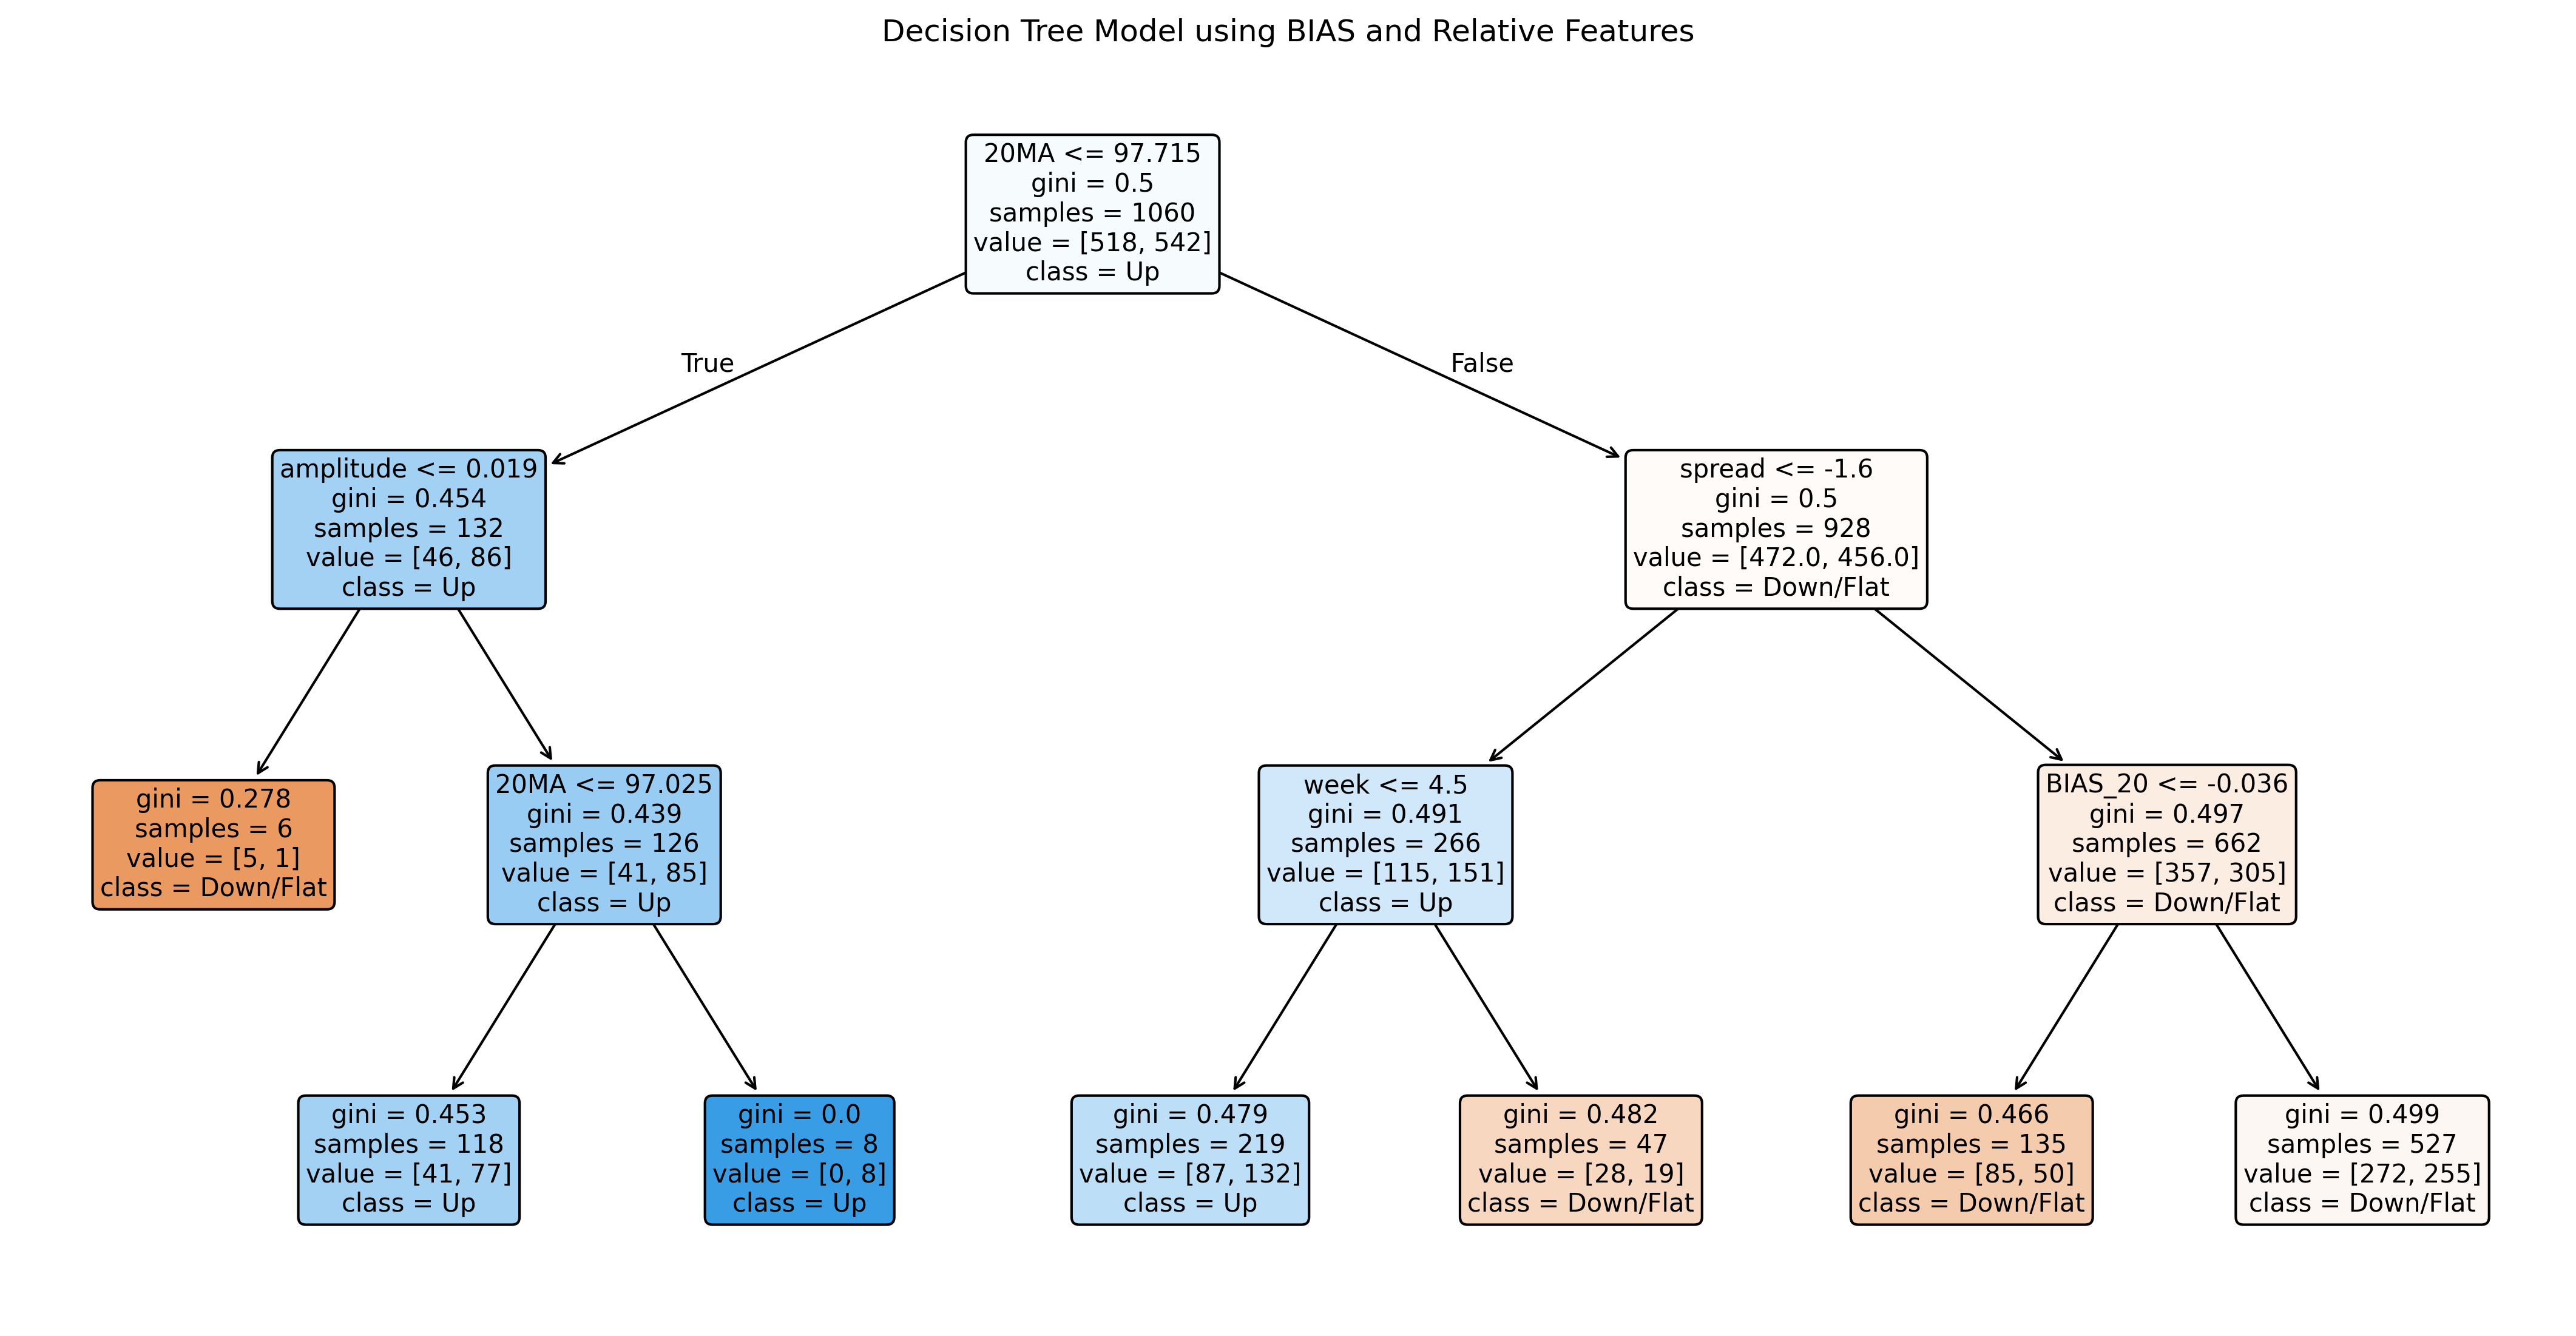

In [32]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 9), dpi=300)
plot_tree(
    model_bias,
    feature_names=X.columns.tolist(),  # 顯示僅包含相對指標的欄位名稱
    class_names=['Down/Flat', 'Up'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Model using BIAS and Relative Features")
plt.show()

##網格搜尋與超參數調校

In [33]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier

# 1. 定義欲搜尋的超參數網格 (Hyperparameter Grid)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

# 2. 設定時序交叉驗證器 (TimeSeriesSplit，確保時間不倒流)
tscv = TimeSeriesSplit(n_splits=5)

# 3. 建立網格搜尋 instance
# scoring='accuracy' 或 'f1'，按需求選擇
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 4. 對訓練集進行網格搜尋擬合
grid_search.fit(X_train, y_train)

# 5. 取得最佳模型與最佳參數
best_model = grid_search.best_estimator_

print("--- 超參數調校完成 ---")
print(f"最佳準確率 (CV Score): {grid_search.best_score_:.4f}")
print("最佳超參數組合：")
print(grid_search.best_params_)

# 6. 使用最佳模型預測測試集並評估
best_y_pred = best_model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print("\n--- 最佳模型在測試集上的表現 ---")
print(f"測試集準確率: {accuracy_score(y_test, best_y_pred):.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
--- 超參數調校完成 ---
最佳準確率 (CV Score): 0.5250
最佳超參數組合：
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 5}

--- 最佳模型在測試集上的表現 ---
測試集準確率: 0.5451


##評估不純度標準比較

In [34]:
# ==========================================
# 評估不純度標準比較 (Gini vs Entropy)
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 1. 分別建立 Gini 與 Entropy 的決策樹模型 (設定相同超參數以公平比較)
model_gini = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
model_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

# 2. 擬合模型
model_gini.fit(X_train, y_train)
model_entropy.fit(X_train, y_train)

# 3. 預測測試集
y_pred_gini = model_gini.predict(X_test)
y_pred_entropy = model_entropy.predict(X_test)

# 4. 建立評估指標比較表
comparison_df = pd.DataFrame({
    '評估指標 (Metric)': ['準確率 (Accuracy)', '精確率 (Precision)', '召回率 (Recall)', 'F1 分數 (F1-Score)'],
    'Gini 不純度': [
        accuracy_score(y_test, y_pred_gini),
        precision_score(y_test, y_pred_gini),
        recall_score(y_test, y_pred_gini),
        f1_score(y_test, y_pred_gini)
    ],
    'Entropy (熵)': [
        accuracy_score(y_test, y_pred_entropy),
        precision_score(y_test, y_pred_entropy),
        recall_score(y_test, y_pred_entropy),
        f1_score(y_test, y_pred_entropy)
    ]
})

print("--- 不純度標準比較結果 ---")
comparison_df

--- 不純度標準比較結果 ---


,評估指標 (Metric),Gini 不純度,Entropy (熵)
0,準確率 (Accuracy),0.537594,0.541353
1,精確率 (Precision),0.437500,0.433962
2,召回率 (Recall),0.243478,0.200000
3,F1 分數 (F1-Score),0.312849,0.273810


###Gini 不純度 與 Entropy熵 是否相等

In [35]:
# 印出 Gini 樹與 Entropy 樹根節點的不純度數值
print(f"Gini 模型根節點的不純度值: {model_gini.tree_.impurity[0]:.4f}")
print(f"Entropy 模型根節點的不純度值: {model_entropy.tree_.impurity[0]:.4f}")

# 檢查兩棵樹預測出的結果是否完全一致
import numpy as np
is_same_pred = np.array_equal(y_pred_gini, y_pred_entropy)
print(f"兩模型對測試集的預測結果是否完全相同: {is_same_pred}")

Gini 模型根節點的不純度值: 0.4997
Entropy 模型根節點的不純度值: 0.9996
兩模型對測試集的預測結果是否完全相同: False


#模型評估與預測結果分析

##混淆矩陣

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 36300 (\N{CJK UNIFIED IDEOGRAPH-8DCC}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 30436 (\N{CJK UNIFIED IDEOGRAPH-76E4}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 28466 (\N{CJK UNIFIED IDEOGRAPH-6F32}) missing from fon

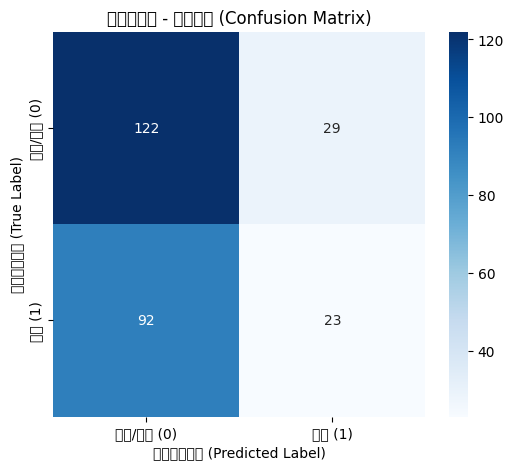

--- 混淆矩陣詳細數值 ---
真負例 (TN) - 預測下跌且正確: 122 筆
偽正例 (FP) - 預測上漲但實際下跌 (假訊號): 29 筆
偽負例 (FN) - 預測下跌但實際上漲 (錯過行情): 92 筆
真正例 (TP) - 預測上漲且正確: 23 筆


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. 使用模型對測試集進行預測
y_pred = model_bias.predict(X_test)

# 2. 計算混淆矩陣數值
cm = confusion_matrix(y_test, y_pred)

# 3. 視覺化混淆矩陣
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['下跌/平盤 (0)', '上漲 (1)'],
            yticklabels=['下跌/平盤 (0)', '上漲 (1)'])

plt.title('決策樹模型 - 混淆矩陣 (Confusion Matrix)')
plt.xlabel('模型預測結果 (Predicted Label)')
plt.ylabel('實際真實結果 (True Label)')
plt.show()

# 4. 印出文字版的四象限數值說明
tn, fp, fn, tp = cm.ravel()
print("--- 混淆矩陣詳細數值 ---")
print(f"真負例 (TN) - 預測下跌且正確: {tn} 筆")
print(f"偽正例 (FP) - 預測上漲但實際下跌 (假訊號): {fp} 筆")
print(f"偽負例 (FN) - 預測下跌但實際上漲 (錯過行情): {fn} 筆")
print(f"真正例 (TP) - 預測上漲且正確: {tp} 筆")

##特徵重要性分析

警告: 'Taipei Sans TC Beta' 字體檔案未找到，請確認已執行下載字體的儲存格。
圖表中的中文字符可能無法正確顯示。
--- 特徵重要性排序數據表 ---
        Feature  Importance
0          20MA    0.371034
1        spread    0.208181
2          week    0.146235
3     amplitude    0.141744
4       BIAS_20    0.132807
5       MA_diff    0.000000
6  daily_return    0.000000


/tmp/ipykernel_1978/521361520.py:52: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1978/521361520.py:52: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1978/521361520.py:52: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1978/521361520.py:52: UserWarning: Glyph 27402 (\N{CJK UNIFIED IDEOGRAPH-6B0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1978/521361520.py:52: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1978/521361520.py:52: UserWarning: Glyph 24501 (\N{CJK UNIFIED IDEOGRAPH-5FB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1978/521361520.py:52: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missi

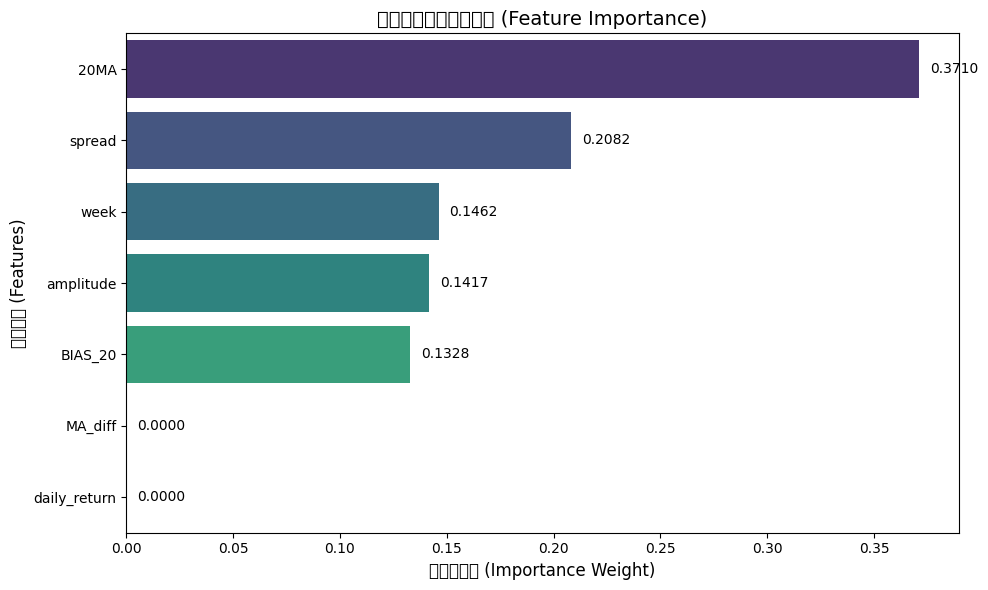

In [37]:
# ==========================================
# 特徵重要性分析與視覺化 (Feature Importance)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 配置 matplotlib 以支援繁體中文顯示
# 確認 /content/TaipeiSansTCBeta-Regular.ttf 檔案存在 (假設已在其他儲存格下載)
try:
    matplotlib.font_manager.fontManager.addfont('/content/TaipeiSansTCBeta-Regular.ttf')
    matplotlib.rc('font', family='Taipei Sans TC Beta')
    print("Matplotlib 已設定為支援繁體中文 'Taipei Sans TC Beta' 字體")
except FileNotFoundError:
    print("警告: 'Taipei Sans TC Beta' 字體檔案未找到，請確認已執行下載字體的儲存格。")
    print("圖表中的中文字符可能無法正確顯示。")

# 1. 從訓練好的模型中提取特徵重要性數值
importances = model_bias.feature_importances_

# 2. 結合特徵欄位名稱建立 DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 3. 顯示特徵重要性數據表
print("--- 特徵重要性排序數據表 ---")
print(feature_importance_df)

# 4. 繪製特徵重要性長條圖 (Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df,
    x='Importance',
    y='Feature',
    hue='Feature', # 添加 hue 參數以解決 FutureWarning
    legend=False,  # 配合 hue 參數，關閉多餘的圖例
    palette='viridis'
)

plt.title('決策樹特徵重要性分析 (Feature Importance)', fontsize=14)
plt.xlabel('重要性權重 (Importance Weight)', fontsize=12)
plt.ylabel('特徵名稱 (Features)', fontsize=12)

# 在長條圖上標示具體數值
for index, value in enumerate(feature_importance_df['Importance']):
    plt.text(value + 0.005, index, f"{value:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

#決策樹最終圖示

/usr/local/lib/python3.12/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.12/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 28466 (\N{CJK UNIFIED IDEOGRAPH-6F32}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.12/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.12/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 36300 (\N{CJK UNIFIED IDEOGRAPH-8DCC}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.12/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_

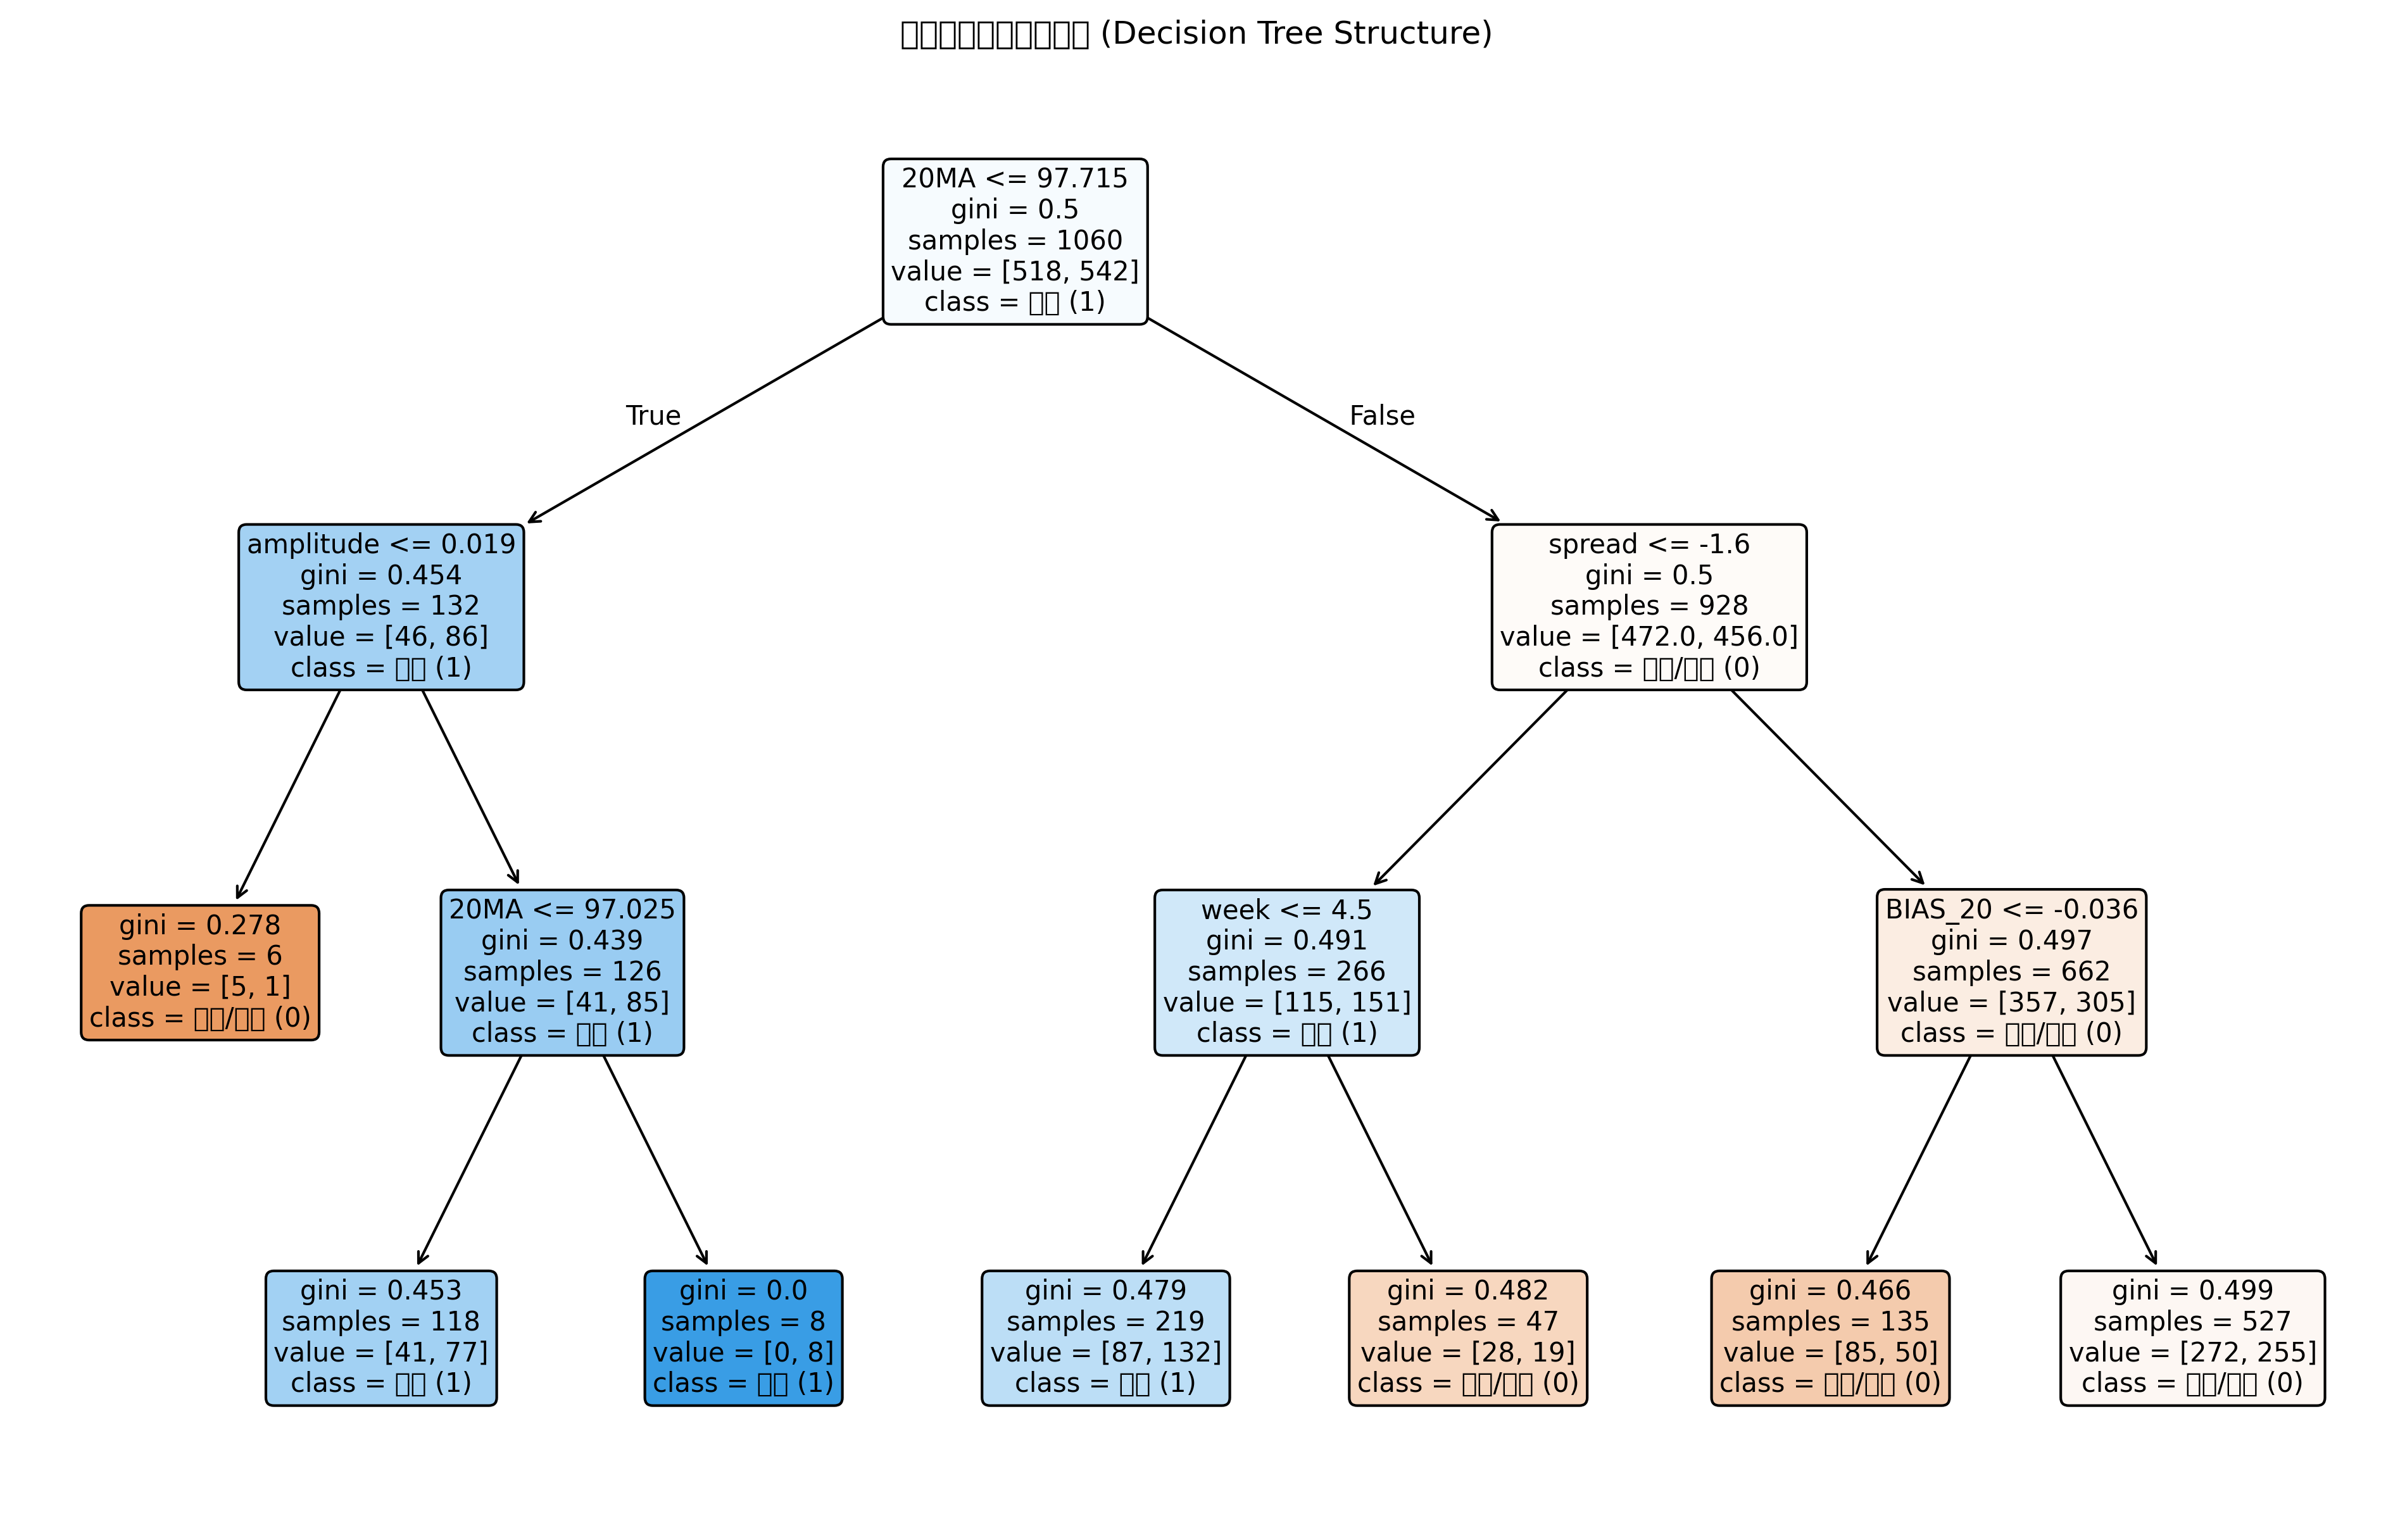

In [38]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 繪製決策樹圖形
plt.figure(figsize=(16, 10), dpi=300)
plot_tree(
    model_bias,
    feature_names=X_train.columns.tolist(),
    class_names=['下跌/平盤 (0)', '上漲 (1)'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("決策樹分類模型結構圖 (Decision Tree Structure)")
plt.show()

#明日預測應用

In [39]:
# 1. 取得最新一個交易日的完整特徵數據 (即 X 矩陣的最後一筆)
latest_feature = X.iloc[[-1]]  # 保持 DataFrame 格式

# 2. 取得該筆數據對應的日期 (若資料庫含有 date 欄位)
if 'date' in df_clean.columns:
    latest_date = df_clean['date'].iloc[-1]
    print(f"最新數據日期: {latest_date}")

# 3. 使用訓練好的決策樹模型進行預測
tomorrow_pred = model_bias.predict(latest_feature)[0]
tomorrow_prob = model_bias.predict_proba(latest_feature)[0]

# 4. 輸出預測結果與解讀
print("\n--- 明日走勢預測結果 (Prediction for Tomorrow) ---")
print(f"模型的預測類別 (Prediction): {tomorrow_pred}")

if tomorrow_pred == 1:
    print(f"策略訊號: 【買進 / 看漲 🟢】")
else:
    print(f"策略訊號: 【觀望 / 看跌或平盤 🔴】")

# 5. 輸出細部機率分布
print(f"\n模型推算明日預測機率：")
print(f" - 下跌/平盤機率 (Class 0): {tomorrow_prob[0] * 100:.2f}%")
print(f" - 上漲機率 (Class 1)    : {tomorrow_prob[1] * 100:.2f}%")

最新數據日期: 2026-07-31 00:00:00

--- 明日走勢預測結果 (Prediction for Tomorrow) ---
模型的預測類別 (Prediction): 0
策略訊號: 【觀望 / 看跌或平盤 🔴】

模型推算明日預測機率：
 - 下跌/平盤機率 (Class 0): 51.61%
 - 上漲機率 (Class 1)    : 48.39%


#---------------------------------------------